Dataset Shape: (8000, 20)

Missing Values:
 CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64

Duplicate Rows: 0

Descriptive Statistics:
         CustomerID          Age         Income      AdSpend  ClickThroughRate  \
count   8000.00000  8000.000000    8000.000000  8000.000000       8000.000000   
mean   11999.50000    43.625500   84664.196750  5000.944830          0.154829   
std     2309.54541    14.902785   37580.387945  2838.038153          0.084007   
min     8000.00000    18.000000   20014.000000   100.054813          0.010

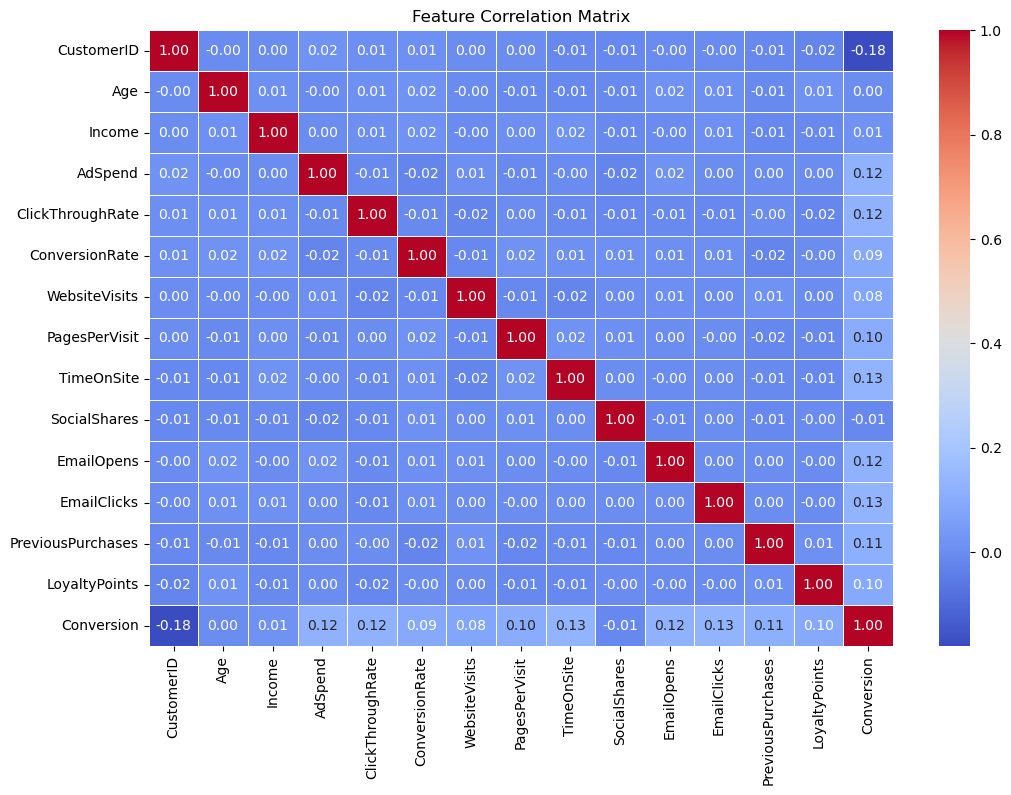


Before SMOTE: Counter({1: 5610, 0: 790})
After SMOTE: Counter({1: 5610, 0: 5610})

--- Logistic Regression ---
Accuracy: 0.766875
Precision: 0.9493449781659389
Recall: 0.775320970042796
F1 Score: 0.8535531998429525
Confusion Matrix:
 [[ 140   58]
 [ 315 1087]]
Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.71      0.43       198
           1       0.95      0.78      0.85      1402

    accuracy                           0.77      1600
   macro avg       0.63      0.74      0.64      1600
weighted avg       0.87      0.77      0.80      1600

Cross-Validation F1 Scores: [0.73429952 0.75631023 0.77465417 0.7698556  0.77676951]
Mean CV F1 Score: 0.762377805770957


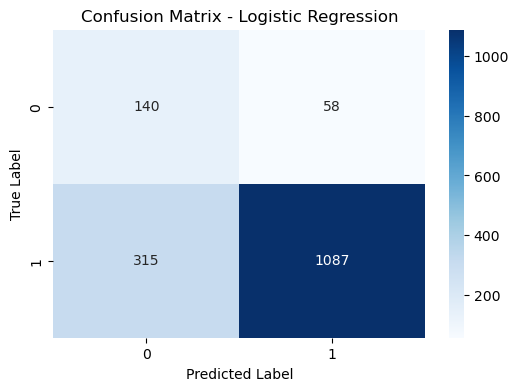


--- Random Forest ---
Accuracy: 0.875
Precision: 0.8842710997442456
Recall: 0.9864479315263909
F1 Score: 0.9325691166554282
Confusion Matrix:
 [[  17  181]
 [  19 1383]]
Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.09      0.15       198
           1       0.88      0.99      0.93      1402

    accuracy                           0.88      1600
   macro avg       0.68      0.54      0.54      1600
weighted avg       0.83      0.88      0.84      1600

Cross-Validation F1 Scores: [0.73476112 0.95898778 0.9587136  0.95853339 0.96098203]
Mean CV F1 Score: 0.914395584719926


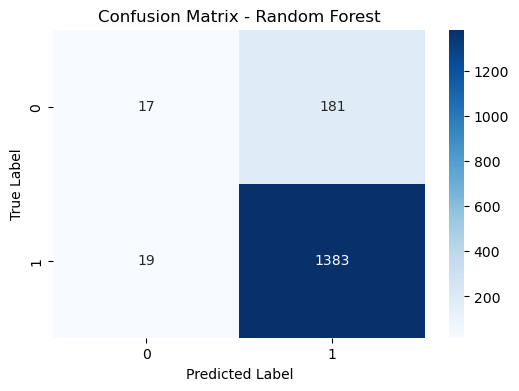


--- Decision Tree ---
Accuracy: 0.806875
Precision: 0.9112114371708051
Recall: 0.8637660485021398
F1 Score: 0.8868546320029294
Confusion Matrix:
 [[  80  118]
 [ 191 1211]]
Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.40      0.34       198
           1       0.91      0.86      0.89      1402

    accuracy                           0.81      1600
   macro avg       0.60      0.63      0.61      1600
weighted avg       0.83      0.81      0.82      1600

Cross-Validation F1 Scores: [0.76074499 0.87038789 0.88691589 0.88011283 0.90028222]
Mean CV F1 Score: 0.8596887637779611


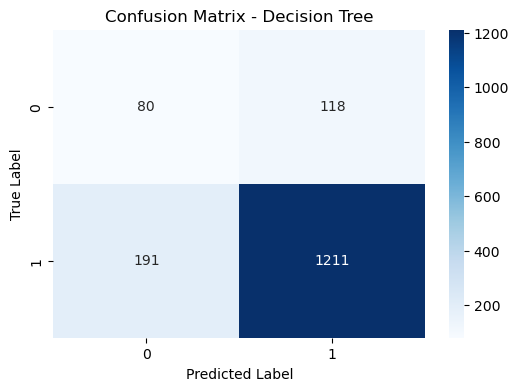


--- Error Checking ---
No feature mismatch between training and test sets.
Test set contains both classes.
Script executed successfully.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# Load the dataset
try:
    df = pd.read_csv("digital_marketing_campaign_dataset.csv")
except FileNotFoundError:
    print("Error: Dataset 'digital_marketing_campaign_dataset.csv' not found.")
    exit()

# --- Exploratory Data Analysis (EDA) ---
# Check dataset shape, missing values, and duplicates
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Descriptive statistics
print("\nDescriptive Statistics:\n", df.describe())

# Categorical variable distributions
print("\nGender Distribution:\n", df["Gender"].value_counts())
print("\nCampaign Channel Distribution:\n", df["CampaignChannel"].value_counts())
print("\nCampaign Type Distribution:\n", df["CampaignType"].value_counts())

# Check skewness of numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
skewness = df[numerical_cols].apply(lambda x: skew(x))
print("\nSkewness of Numerical Features:\n", skewness)

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

# --- Data Preprocessing ---
# Drop irrelevant columns
df = df.drop(['CustomerID', 'AdvertisingPlatform', 'AdvertisingTool'], axis=1)

# Define features and target
X = df.drop('Conversion', axis=1)
y = df['Conversion']

# Train-test split (before preprocessing to prevent leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Feature Engineering ---
# Encode categorical variables
categorical_cols = ['Gender', 'CampaignChannel', 'CampaignType']
encoder = OneHotEncoder(sparse_output=False, drop='first')
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[categorical_cols]), 
                               columns=encoder.get_feature_names_out(categorical_cols), 
                               index=X_train.index)
X_test_encoded = pd.DataFrame(encoder.transform(X_test[categorical_cols]), 
                              columns=encoder.get_feature_names_out(categorical_cols), 
                              index=X_test.index)

# Drop original categorical columns and concatenate encoded ones
X_train = X_train.drop(categorical_cols, axis=1)
X_test = X_test.drop(categorical_cols, axis=1)
X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)

# Handle skewness for highly skewed features (|skewness| > 1)
skewed_cols = skewness[abs(skewness) > 1].index
for col in skewed_cols:
    if col in X_train.columns and col != 'Conversion':
        X_train[col + '_skewed'] = np.log1p(X_train[col])
        X_test[col + '_skewed'] = np.log1p(X_test[col])

# Drop original skewed columns if transformed
for col in skewed_cols:
    if col in X_train.columns and col != 'Conversion':
        X_train = X_train.drop(col, axis=1)
        X_test = X_test.drop(col, axis=1)

# Apply SMOTE to handle class imbalance (only on training set)
print("\nBefore SMOTE:", Counter(y_train))
smote = SMOTE(random_state=42)
try:
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print("After SMOTE:", Counter(y_train_smote))
except ValueError as e:
    print("Error during SMOTE:", e)
    exit()

# Scale features
scaler = StandardScaler()
X_train_smote = scaler.fit_transform(X_train_smote)
X_test = scaler.transform(X_test)

# --- Model Training ---
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_leaf_nodes=30, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42)
}

# Train and evaluate models
for name, model in models.items():
    print(f"\n--- {name} ---")
    try:
        # Train model
        model.fit(X_train_smote, y_train_smote)
        y_pred = model.predict(X_test)
        
        # Evaluation metrics
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print("Precision:", precision_score(y_test, y_pred))
        print("Recall:", recall_score(y_test, y_pred))
        print("F1 Score:", f1_score(y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("Classification Report:\n", classification_report(y_test, y_pred))
        
        # Cross-validation score
        cv_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring='f1')
        print("Cross-Validation F1 Scores:", cv_scores)
        print("Mean CV F1 Score:", cv_scores.mean())

        # Plot confusion matrix
        plt.figure(figsize=(6, 4))
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
        plt.title(f"Confusion Matrix - {name}")
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
    except Exception as e:
        print(f"Error training/evaluating {name}:", e)

# --- Error Checking ---
print("\n--- Error Checking ---")
if df.isnull().sum().sum() > 0:
    print("Warning: Missing values detected in the dataset.")
if df.duplicated().sum() > 0:
    print("Warning: Duplicate rows detected in the dataset.")
if X_train_smote.shape[1] != X_test.shape[1]:
    print("Error: Feature mismatch between training and test sets.")
else:
    print("No feature mismatch between training and test sets.")
if Counter(y_test)[0] == 0 or Counter(y_test)[1] == 0:
    print("Error: Test set contains only one class.")
else:
    print("Test set contains both classes.")
print("Script executed successfully.")